In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import isodate
import calendar

In [2]:
df = pd.read_csv(r'C:\Users\raull\Documents\rm\py\jupyter\Projects\analysis-channel-ytb\cintikahome_result.csv')

In [3]:
df.head()

,Unnamed: 0,Title,videoPublishedAt,viewCount,likeCount,commentCount,favoriteCount,duration,categoryId
0,0,La decoración de la casa del pueblo de mi madre 👀,2026-04-07T19:00:29Z,17833,2545,272,0,PT11M42S,26
1,1,Rincón de cafecito en el jardín por 60€ ‼️ sof...,2026-04-03T18:00:22Z,12598,1604,202,0,PT20M3S,26
2,2,Sofá de jardín en la basura! 😱 voy a la tienda...,2026-04-01T19:00:34Z,13659,1557,110,0,PT16M28S,26
3,3,Mi compra del Action 60€ 👀 novedades en decor...,2026-03-30T18:51:45Z,9942,1144,58,0,PT16M50S,26
4,4,Tienda gigante de segunda mano ‼️ otras opcion...,2026-03-27T20:04:06Z,9082,1220,57,0,PT11M,26


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 404 entries, 0 to 403
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Unnamed: 0        404 non-null    int64
 1   Title             404 non-null    str  
 2   videoPublishedAt  404 non-null    str  
 3   viewCount         404 non-null    int64
 4   likeCount         404 non-null    int64
 5   commentCount      404 non-null    int64
 6   favoriteCount     404 non-null    int64
 7   duration          404 non-null    str  
 8   categoryId        404 non-null    int64
dtypes: int64(6), str(3)
memory usage: 28.5 KB


In [5]:
# Cleaning

In [6]:
df.drop(columns=['Unnamed: 0'], inplace=True)

In [7]:
iso8601_duration = df['duration'].to_numpy()
seconds_duration = []
for i in iso8601_duration:
    seconds_duration.append(isodate.parse_duration(i).total_seconds())

In [8]:
df['duration'] = seconds_duration

In [9]:
iso8601_datetime = df['videoPublishedAt'].to_numpy()
datetime_date = []
for i in iso8601_datetime:
    datetime_date.append(isodate.parse_datetime(i))

In [10]:
df['videoPublishedAt'] = datetime_date

In [11]:
df.head()

,Title,videoPublishedAt,viewCount,likeCount,commentCount,favoriteCount,duration,categoryId
0,La decoración de la casa del pueblo de mi madre 👀,2026-04-07 19:00:29+00:00,17833,2545,272,0,702.0,26
1,Rincón de cafecito en el jardín por 60€ ‼️ sof...,2026-04-03 18:00:22+00:00,12598,1604,202,0,1203.0,26
2,Sofá de jardín en la basura! 😱 voy a la tienda...,2026-04-01 19:00:34+00:00,13659,1557,110,0,988.0,26
3,Mi compra del Action 60€ 👀 novedades en decor...,2026-03-30 18:51:45+00:00,9942,1144,58,0,1010.0,26
4,Tienda gigante de segunda mano ‼️ otras opcion...,2026-03-27 20:04:06+00:00,9082,1220,57,0,660.0,26


In [12]:
# Analysis

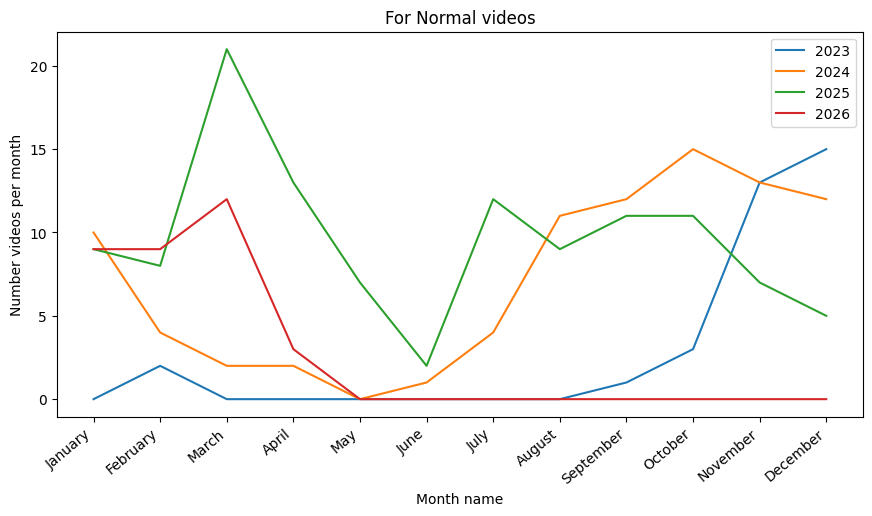

In [13]:
# How many videos per month ('Normal' videos)

years = [2023, 2024, 2025, 2026]
months_name = list(calendar.month_name)[1:]

fig, axes = plt.subplots(figsize=[10.4, 5])
# print(df[df['videoPublishedAt'].dt.year == 2025]['videoPublishedAt'].sort_values().dt.month_name().unique())_filled
for year in years:
    number_videos_per_month = df[(df['videoPublishedAt'].dt.year == year) & (df['duration'] >= 180.0)].groupby(df['videoPublishedAt'].dt.month).size()
    number_videos_per_month_filled = np.array([number_videos_per_month.get(i, 0) for i in range(1, 13)])
    axes.plot(months_name, number_videos_per_month_filled, label=str(year))

axes.set_xticks(axes.get_xticks())
axes.set_xticklabels(axes.get_xticklabels(), rotation=40, ha='right')
plt.ylabel('Number videos per month')
plt.xlabel('Month name')
plt.title('For Normal videos')

# there are between 8-10 normal videos per month since 2024

# it shows the duration of his month sorted
#print(df[(df['videoPublishedAt'].dt.year == 2025) & (df['duration'] >= 180.0)].groupby(df['videoPublishedAt'].dt.month)['duration'].median())
#print(df[(df['videoPublishedAt'].dt.year == 2025) & (df['duration'] >= 180.0) & (df['videoPublishedAt'].dt.month == 3)].median(numeric_only=True))

plt.legend()
plt.show()

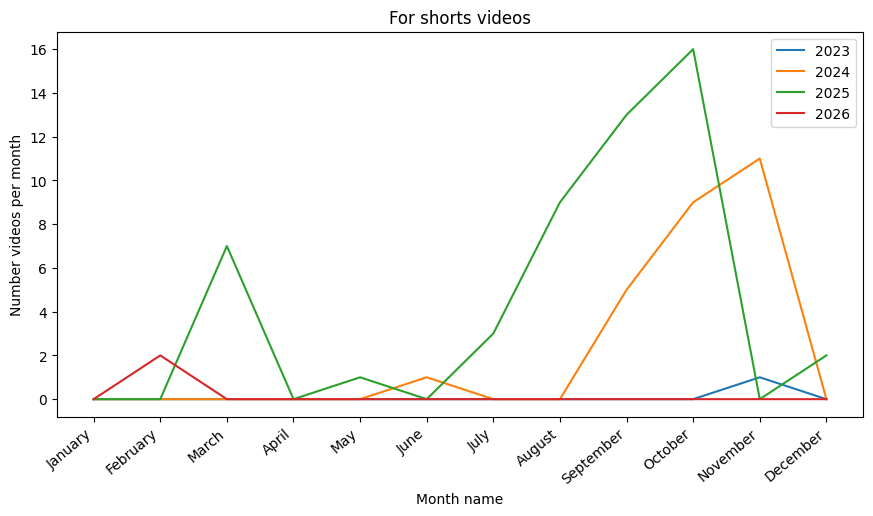

In [14]:
# How many videos per month ('Shorts' videos)

years = [2023, 2024, 2025, 2026]
months_name = list(calendar.month_name)[1:]

fig, axes = plt.subplots(figsize=[10.4, 5])
# print(df[df['videoPublishedAt'].dt.year == 2025]['videoPublishedAt'].sort_values().dt.month_name().unique())_filled
for year in years:
    number_videos_per_month = df[(df['videoPublishedAt'].dt.year == year) & (df['duration'] <= 180.0)].groupby(df['videoPublishedAt'].dt.month).size()
    number_videos_per_month_filled = np.array([number_videos_per_month.get(i, 0) for i in range(1, 13)])
    axes.plot(months_name, number_videos_per_month_filled, label=str(year))
    
axes.set_xticks(axes.get_xticks())
axes.set_xticklabels(axes.get_xticklabels(), rotation=40, ha='right')
plt.ylabel('Number videos per month')
plt.xlabel('Month name')
plt.title('For shorts videos')
plt.legend()
plt.show()

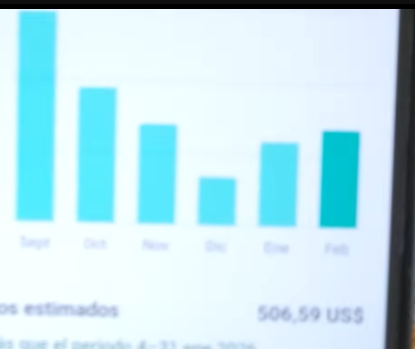

In [15]:
# print(df[(df['videoPublishedAt'].dt.month == 2) & (df['videoPublishedAt'].dt.year == 2026)].sum(numeric_only=True))

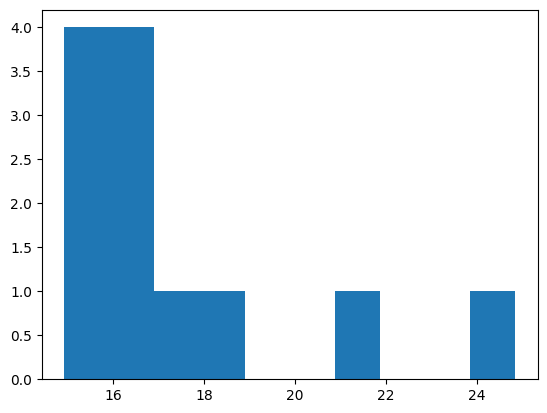

In [16]:
# # Median duration ('Normal' videos)

# duration > 180.0 to avoid shorts
median_videos_duration = df[(df['videoPublishedAt'].dt.year >= 2025) & (df['duration'] > 180.0)].groupby(df['videoPublishedAt'].dt.month)['duration'].median().to_numpy()
median_videos_duration = median_videos_duration / 60

plt.hist(median_videos_duration)
plt.show()

In [17]:
years = [2024, 2025, 2026]

for y in years:
    for month in range(13):
        sum_mont = df[(df['videoPublishedAt'].dt.year == y) & (df['videoPublishedAt'].dt.month == month)]['viewCount'].sum()
        indexes = df[(df['videoPublishedAt'].dt.year == y) & (df['videoPublishedAt'].dt.month == month)].index
        df.loc[indexes, 'viewMonth'] = sum_mont

#print(df[(df['videoPublishedAt'].dt.year == 2026) & (df['videoPublishedAt'].dt.month == 1)])
df['percentageViewMonth'] = np.round((df['viewCount'] / df['viewMonth']) * 100, 2)


In [18]:
dictionary = {}

years = [2024, 2025, 2026]
list_videos = df[df['percentageViewMonth']  >= 20][['videoPublishedAt','Title', 'viewCount', 'viewMonth', 'percentageViewMonth', 'duration']].sort_values(by='videoPublishedAt').to_numpy()
print(list_videos)

for i, v in enumerate(list_videos):
    key = str(v[0].to_period('M'))  # conviertes a str una sola vez
    if key not in dictionary:
        dictionary[key] = []
    dictionary[str(v[0].to_period('M'))].append({'Title':v[1], 'Visualizations':v[2], 'Month_Visualizations':v[3]
                                           , 'Percentage_Month_Visualizations':v[4], 'duration':v[5] / 60})


[[Timestamp('2024-02-12 19:23:00+0000', tz='<isodate.tzinfo.Utc object at 0x0000018AE9B39FD0>')
  '🟢 Sección hogar en el Action y cosas que utilizo en mi casa 🏡' 10468
  40501.0 25.85 652.0]
 [Timestamp('2024-02-19 12:32:02+0000', tz='<isodate.tzinfo.Utc object at 0x0000018AE9B39FD0>')
  '🟢 SOMOS RICOS ¡Mesa a 0,50€! Tienda de segunda mano ✋️mueble para mis cosas de costura 😃'
  14135 40501.0 34.9 724.0]
 [Timestamp('2024-02-22 15:52:30+0000', tz='<isodate.tzinfo.Utc object at 0x0000018AE9B39FD0>')
  '🟣  Limpiando la casa tras semanas de virus en casa 😷' 10124 40501.0
  25.0 958.0]
 [Timestamp('2024-03-06 18:50:00+0000', tz='<isodate.tzinfo.Utc object at 0x0000018AE9B39FD0>')
  '🟢 Tienda de segunda mano en Bélgica: muchas antigüedades 😃' 6479
  14467.0 44.78 698.0]
 [Timestamp('2024-03-22 14:14:00+0000', tz='<isodate.tzinfo.Utc object at 0x0000018AE9B39FD0>')
  '🟣 Limpio la mini cocina de 8 personas por la noche' 7988 14467.0 55.22
  944.0]
 [Timestamp('2024-04-03 19:16:46+0000', tz='<

C:\Users\raull\AppData\Local\Temp\ipykernel_1188\123813807.py:8: UserWarning: Converting to Period representation will drop timezone information.
  key = str(v[0].to_period('M'))  # conviertes a str una sola vez
C:\Users\raull\AppData\Local\Temp\ipykernel_1188\123813807.py:11: UserWarning: Converting to Period representation will drop timezone information.
  dictionary[str(v[0].to_period('M'))].append({'Title':v[1], 'Visualizations':v[2], 'Month_Visualizations':v[3]


In [19]:
dictionary

{'2024-02': [{'Title': '🟢 Sección hogar en el Action y cosas que utilizo en mi casa 🏡',
   'Visualizations': 10468,
   'Month_Visualizations': 40501.0,
   'Percentage_Month_Visualizations': 25.85,
   'duration': 10.866666666666667},
  {'Title': '🟢 SOMOS RICOS ¡Mesa a 0,50€! Tienda de segunda mano ✋️mueble para mis cosas de costura 😃',
   'Visualizations': 14135,
   'Month_Visualizations': 40501.0,
   'Percentage_Month_Visualizations': 34.9,
   'duration': 12.066666666666666},
  {'Title': '🟣  Limpiando la casa tras semanas de virus en casa 😷',
   'Visualizations': 10124,
   'Month_Visualizations': 40501.0,
   'Percentage_Month_Visualizations': 25.0,
   'duration': 15.966666666666667}],
 '2024-03': [{'Title': '🟢 Tienda de segunda mano en Bélgica: muchas antigüedades 😃',
   'Visualizations': 6479,
   'Month_Visualizations': 14467.0,
   'Percentage_Month_Visualizations': 44.78,
   'duration': 11.633333333333333},
  {'Title': '🟣 Limpio la mini cocina de 8 personas por la noche',
   'Visuali

In [20]:
print(df['viewMonth'].unique())

[ 44090. 137351. 130904. 119473.  78222.  83099. 271945. 352190. 288708.
 308166.  34832.  90783. 157564. 275946.  64137. 103611. 129356. 160172.
 250126. 130149.  76110.  10774.  14359.  18944.  14467.  40501. 111434.
     nan]


In [21]:
df['yearMonth'] = df['videoPublishedAt'].dt.to_period('M')
        

C:\Users\raull\AppData\Local\Temp\ipykernel_1188\3559886164.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['yearMonth'] = df['videoPublishedAt'].dt.to_period('M')


In [22]:
print(df.groupby('yearMonth')['viewMonth'].max())

yearMonth
2016-12         NaN
2017-01         NaN
2017-03         NaN
2018-03         NaN
2018-09         NaN
2018-12         NaN
2019-01         NaN
2019-07         NaN
2019-08         NaN
2019-09         NaN
2019-10         NaN
2019-11         NaN
2020-02         NaN
2020-06         NaN
2020-08         NaN
2020-11         NaN
2020-12         NaN
2021-01         NaN
2021-08         NaN
2022-01         NaN
2022-02         NaN
2022-03         NaN
2022-04         NaN
2022-05         NaN
2022-07         NaN
2023-02         NaN
2023-09         NaN
2023-10         NaN
2023-11         NaN
2023-12         NaN
2024-01    111434.0
2024-02     40501.0
2024-03     14467.0
2024-04     18944.0
2024-06     14359.0
2024-07     10774.0
2024-08     76110.0
2024-09    130149.0
2024-10    250126.0
2024-11    160172.0
2024-12    129356.0
2025-01    103611.0
2025-02     64137.0
2025-03    275946.0
2025-04    157564.0
2025-05     90783.0
2025-06     34832.0
2025-07    308166.0
2025-08    288708.0
2025-09   

In [23]:
print(df[df['videoPublishedAt'].dt.year == 2024])

                                                 Title  \
201  #HAUL de SHEIN: Las cestas de ropa para mi ARM...   
202  Porqué no he pintado el sótano antes de poner ...   
203  ✨️ te SORPRENDERÁ este ARMARIO para el hueco d...   
204  Cómo limpio el sótano 📢 Limpieza extrema: 4 añ...   
205  Súper unboxing de Shein 💰 el que más me he gas...   
..                                                 ...   
308  🟡 CAMBIO RADICAL de la entrada ¡Por fuera! pin...   
309  🟡 Charlamos  mientras abro PAQUETES! 😃 Que CAM...   
310  🟣 Limpieza después de vacaciones mientras os c...   
311  ¡La casa de mis sueños! 😲 Home tour de nuestra...   
312  🟣 Doblando montañas de ropa 😱 colada de famili...   

             videoPublishedAt  viewCount  likeCount  commentCount  \
201 2024-12-25 14:29:55+00:00      12121       1486           145   
202 2024-12-23 11:29:21+00:00      11369       1493           171   
203 2024-12-22 15:06:18+00:00      10277       1473           163   
204 2024-12-15 15:58:40+00: